In [ ]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import pickle
from joblib import Parallel, delayed

In [2]:
from rc import ESN, ESNConfig

In [408]:
pendulum_data = np.load('../results_data/s.npy').T

In [409]:
pendulum_data.shape

(4, 5000000)

In [370]:
dt = 0.05
dt_orig = 0.001
resample_factor = int(dt / dt_orig)

In [371]:
pendulum_data = pendulum_data[:2, ::resample_factor][:, :]

In [410]:
pendulum_data.shape

(4, 5000000)

In [411]:
dts = np.linspace(0.01, 0.1, 10)

In [430]:
config = ESNConfig(
    N=700,
    input_dim=2,
    spectral_radius=0.1,
    alpha=9.73476523974807e-07,
    sparsity=0.99,
    input_scaling=1,
    bias_scaling=0.1,
    seed=None,
    mode="leaky",
    leaky_rate=0.06402723031574233,
)

In [404]:
esn = ESN(config)
esn.train(pendulum_data, washout=10000)

In [406]:
lyapunov_spectrum = esn.lyapunov_spectrum(pendulum_data,
                                        num_lyaps=4,
                                        steps=5000,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=1000)


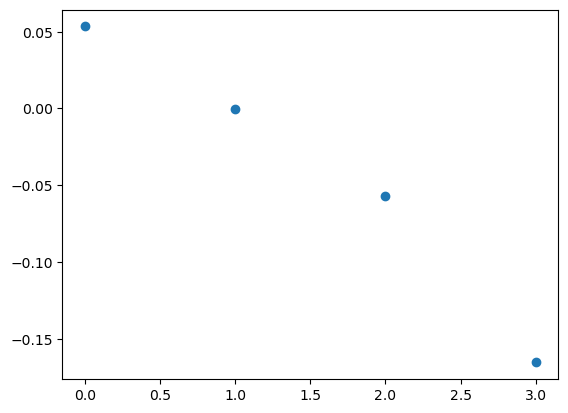

In [407]:
plt.plot(lyapunov_spectrum['mean'][:4], 'o')

In [ ]:

def compute_spectrum(dt, i, dt_orig, pendulum_data, config):
    print(f"Computing dt={dt}, iteration={i}")
    resample_factor = int(dt / dt_orig)
    train_data = pendulum_data[:2, ::resample_factor][:, :]
    
    washout_scaled = int(2000 * (10 / resample_factor))
    steps_scaled = int(4000 * (10 / resample_factor))
    
    config_copy = ESNConfig(
        N=config.N,
        input_dim=config.input_dim,
        spectral_radius=config.spectral_radius,
        alpha=config.alpha,
        sparsity=config.sparsity,
        input_scaling=config.input_scaling,
        bias_scaling=config.bias_scaling,
        seed=config.seed,
        mode=config.mode,
        leaky_rate=config.leaky_rate,
    )
    esn = ESN(config_copy)
    esn.train(train_data, washout=washout_scaled)
    lyapunov_spectrum = esn.lyapunov_spectrum(train_data,
                                        num_lyaps=8,
                                        steps=steps_scaled,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=1000)
    return lyapunov_spectrum

spctrums = []

for dt in dts:
    spectrum_within_dt = Parallel(n_jobs=-2)(
        delayed(compute_spectrum)(dt, i, dt_orig, pendulum_data, config) 
        for i in range(10)
    )
    spctrums.append(spectrum_within_dt)
    print(f"Completed dt={dt}, mean: {spectrum_within_dt[0]['mean']}")
    

Computing dt=0.01, iteration=8
Computing dt=0.01, iteration=2
Computing dt=0.01, iteration=6
Computing dt=0.01, iteration=3
Computing dt=0.01, iteration=0
Computing dt=0.01, iteration=7
Computing dt=0.01, iteration=4
Computing dt=0.01, iteration=1Computing dt=0.01, iteration=5

Computing dt=0.01, iteration=9
Completed dt=0.01, mean: [ 5.18454283e-02 -1.99725806e-03 -6.19797267e-02 -8.62715448e-02
 -5.31610464e+00 -5.71070938e+00 -6.06001614e+00 -6.11512669e+00]
Computing dt=0.020000000000000004, iteration=5
Computing dt=0.020000000000000004, iteration=4
Computing dt=0.020000000000000004, iteration=3
Computing dt=0.020000000000000004, iteration=8
Computing dt=0.020000000000000004, iteration=1
Computing dt=0.020000000000000004, iteration=7
Computing dt=0.020000000000000004, iteration=2
Computing dt=0.020000000000000004, iteration=0
Computing dt=0.020000000000000004, iteration=6
Computing dt=0.020000000000000004, iteration=9
Completed dt=0.020000000000000004, mean: [ 0.11754196  0.0121819

In [ ]:

with open('../results_data/spctrums_dp_pendulum.pkl', 'wb') as f:
    pickle.dump(spctrums, f)


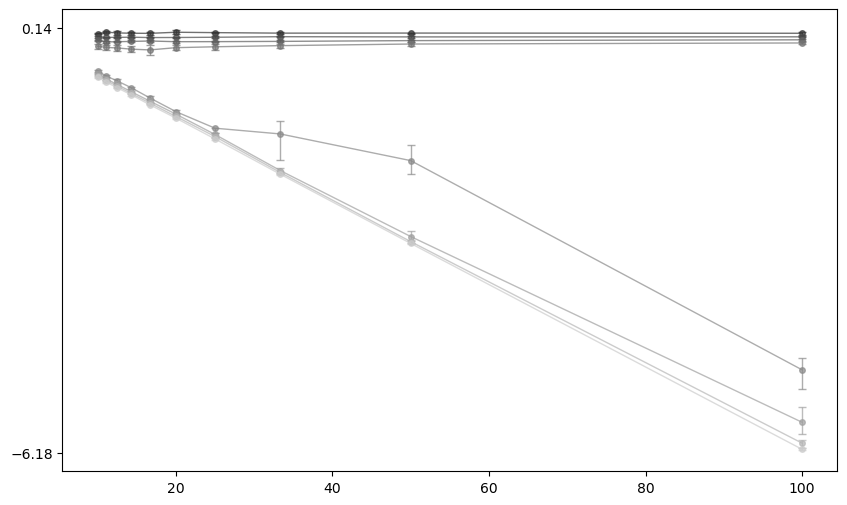

In [435]:
fig, ax = plt.subplots(figsize=(10, 6))

num_exponents = len(spctrums[0][0]["mean"])

colors = plt.cm.gray(np.linspace(0.2, 0.8, num_exponents))

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

for exponent_idx in range(num_exponents):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.mean([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.mean(data)
        exponent_errors_lower.append(abs(mean_val - lower))
        exponent_errors_upper.append(abs(upper - mean_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=colors[exponent_idx], label=f'λ_{exponent_idx+1}')


ax.set_yticks([min([min([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)]), 
               max([max([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)])])
ax.minorticks_off()


plt.show()


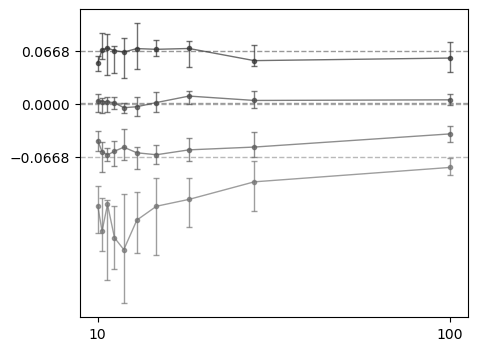

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.median([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.median(data)
        exponent_errors_lower.append(mean_val - lower)
        exponent_errors_upper.append(upper - mean_val)
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=3, linewidth=1, alpha=0.7, capsize=2, color=colors[exponent_idx])

real_lyapunov = [0.06679198, 0.00059611, -0.00055851, -0.06684586]
for exponent_idx in range(4):
    ax.axhline(y=real_lyapunov[exponent_idx], linestyle='--', linewidth=1, alpha=0.5, color=colors[exponent_idx])

ax.set_xticks([min(inv_dts), max(inv_dts)])
ax.set_yticks([real_lyapunov[-1], 0, real_lyapunov[0]])
ax.minorticks_off()
plt.savefig('supplemend_dt_pendulum.svg', format='svg', bbox_inches='tight')
plt.savefig('supplemend_dt_pendulum.pdf', format='pdf', bbox_inches='tight')
plt.show()


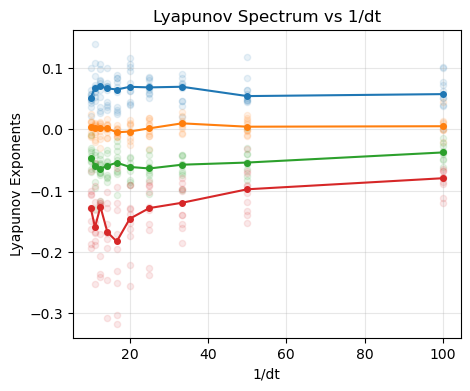

In [438]:
plt.figure(figsize=(5, 4))

colors = ['C0', 'C1', 'C2', 'C3']

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    color = colors[exponent_idx]
    for dt_idx, spectrum_list in enumerate(spctrums):
        inv_dt = inv_dts[dt_idx]
        exponent_values = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        plt.scatter([inv_dt] * len(exponent_values), exponent_values, s=20, alpha=0.1, color=color)
    
    mean_values = [
        np.median([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    plt.plot(inv_dts, mean_values, marker='o', markersize=4, linewidth=1.5, alpha=1.0, color=color)

plt.xlabel('1/dt')
plt.ylabel('Lyapunov Exponents')
plt.title('Lyapunov Spectrum vs 1/dt')
plt.grid(True, alpha=0.3)
plt.show()


In [340]:
from rc import ESNSearchSpaceBuilder


space = (ESNSearchSpaceBuilder()
    .optimize("spectral_radius", bounds=(0.01, 2))  
    .optimize("alpha")
    .optimize("input_scaling", bounds=(0.01, 3))
    .optimize("bias_scaling", bounds=(0.01, 2))
    .optimize("leaky_rate", bounds=(0.01, 1))
    .fix(N=700, mode="leaky", sparsity=0.99)
    .build())

In [341]:
from rc import EvaluationConfig


config_eval = EvaluationConfig(
    washout=2000,
    warmup_steps=2000,
    predict_steps=10000,
    n_predictions=5,   
    n_instances=5,     
    metrics=['wasserstein'],
    wasserstein_projections=100,
    clip_wasserstein=3,
    constrain_cle=True,
    cle_threshold=-12,
    dt=dt
)

In [342]:
pendulum_data.shape

(2, 100000)

In [373]:
import warnings
import logging

from rc import optimize_esn

logging.getLogger('ax').setLevel(logging.ERROR)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='botorch')
warnings.filterwarnings('ignore', module='gpytorch')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='linear_operator')

best_params, best_params_overall, ax_client = optimize_esn(data = pendulum_data[:, :50000], space = space, config = config_eval, n_trials = 80)

[INFO 02-05 22:08:08] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 02-05 22:08:08] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='Sobol+BoTorch', steps=[Sobol for 10 trials, BoTorch for subsequent trials]). Iterations after 10 will take longer to generate due to model-fitting.


{'spectral_radius': 1.4668468755483628, 'alpha': 0.0020940341863199957, 'input_scaling': 2.991348947286606, 'bias_scaling': 0.18112436369061471, 'leaky_rate': 0.23440320849418642}
{'wasserstein': (np.float64(2.5957211113682357), np.float64(0.3203020527493335)), 'max_cle': (np.float64(-2.585139008607508), np.float64(0.0904528684219216))}
{'spectral_radius': 0.20229393268004062, 'alpha': 4.626475056163059e-08, 'input_scaling': 0.9880257541220636, 'bias_scaling': 1.3574406462814659, 'leaky_rate': 0.6315447680000216}
{'wasserstein': (np.float64(0.07828727380591947), np.float64(0.006974290160828555)), 'max_cle': (np.float64(-16.43280676812594), np.float64(0.09855492178259606))}
{'spectral_radius': 0.8713406410627067, 'alpha': 0.00020475378607338535, 'input_scaling': 1.8032864980027081, 'bias_scaling': 0.6166449279990047, 'leaky_rate': 0.9594827435724437}
{'wasserstein': (np.float64(2.049124405633189), np.float64(0.23771515418435307)), 'max_cle': (np.float64(-16.2140404931485), np.float64(0.

In [374]:
final_config = space.build_config(best_params, input_dim=pendulum_data.shape[0])

In [375]:
final_config

ESNConfig(N=700, input_dim=2, spectral_radius=0.20717252125527272, alpha=8.471570675600426e-08, sparsity=0.99, input_scaling=1.1535399452644315, bias_scaling=1.7429314115032362, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.5583643953980046, beta=0.5, scale=0.1)

In [376]:
esn = ESN(final_config)

In [377]:
states_train = esn.train(pendulum_data[:, :50000], washout=2000, return_states=True)

In [395]:
lyapunov_spectrum = esn.lyapunov_spectrum(pendulum_data[:, :50000],
                                        num_lyaps=7,
                                        steps=6000,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=500)


In [401]:
lyapunov_spectrum

{'mean': array([ 6.23058009e-02,  4.29004103e-03, -2.55647361e-02, -7.82971722e-02,
        -1.28015542e+01, -1.32587578e+01, -1.34594204e+01]),
 'std': array([0.01839682, 0.00741358, 0.01607347, 0.02432122, 0.12722623,
        0.04675758, 0.08161773]),
 'all_samples': array([[ 6.80070398e-02,  8.14762117e-03, -9.74665799e-03,
         -9.72445426e-02, -1.28015542e+01, -1.32587578e+01,
         -1.34434889e+01],
        [ 5.04422108e-02,  2.27907232e-03, -2.55647361e-02,
         -7.55835892e-02, -1.28375888e+01, -1.32037561e+01,
         -1.35433398e+01],
        [ 6.57352488e-02,  2.16517631e-02, -5.62656317e-02,
         -7.82971722e-02, -1.27966943e+01, -1.33149568e+01,
         -1.34594204e+01],
        [ 6.23058009e-02,  4.29004103e-03, -3.32296641e-02,
         -7.93745279e-02, -1.28140145e+01, -1.33172448e+01,
         -1.35159542e+01],
        [ 1.81905701e-02,  1.45244001e-03, -1.67372625e-02,
         -2.49079823e-02, -1.24963712e+01, -1.32210281e+01,
         -1.33078922e+0

In [399]:
predictions, states = esn.predict(warmup=pendulum_data[:, -2000:], steps=4000)

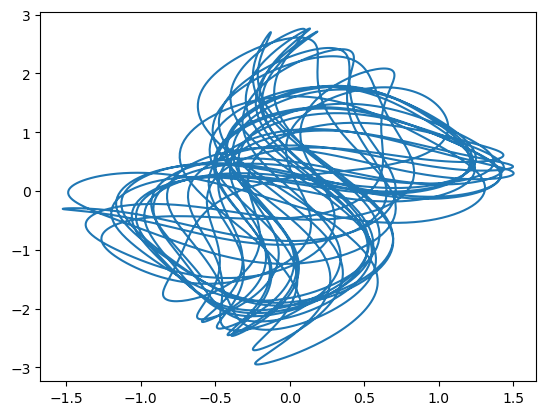

In [400]:
plt.plot(predictions[0, :], predictions[1, :])
plt.show()